# Can Student Schedules Predict Burnout?

**A machine learning project on the hidden cost of being busy.**

---

Burnout in students is usually blamed on one thing — too much homework, too little sleep, too much screen time. But real lives are made of *combinations*: a packed schedule with strong family support feels very different from a packed schedule without it.

This notebook asks a simple question: **given a student's daily schedule, can we predict whether they feel highly burned out?**

We walk through:
1. **Exploratory data analysis** — what does the data actually look like?
2. **Single-variable patterns** — how does sleep, homework, screen time, support each relate to burnout?
3. **Predictive modeling** — logistic regression, random forest, gradient boosting
4. **Feature importance** — what actually drives burnout, after controlling for everything else?
5. **Schedule profiles via clustering** — discovering "types" of students
6. **Takeaways** — what a school counselor could actually do with this

> **Note on data:** the dataset is synthetic but generated from realistic relationships drawn from adolescent health literature. The pipeline is designed so swapping in a real survey CSV (e.g. from a class project or Kaggle competition) requires no code changes — just point at a new file.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = 42

print("Setup complete.")

Setup complete.


## 2. Load the data

The dataset has one row per student and includes:

| Group | Columns |
|---|---|
| Demographic | `grade`, `gender` |
| Sleep | `sleep_hours`, `sleep_quality` |
| Schoolwork | `homework_hours`, `tests_per_week` |
| Activities | `extracurricular_hours`, `num_activities` |
| Lifestyle | `screen_time_hours`, `commute_minutes` |
| Support | `family_support`, `friend_support`, `teacher_support` |
| Self-report | `self_rated_stress`, `burnout_score` |
| **Target** | `high_burnout` (1 if burnout_score ≥ 4, else 0) |


In [2]:
df = pd.read_csv("../data/student_burnout.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (2000, 17)


,student_id,grade,gender,sleep_hours,sleep_quality,homework_hours,tests_per_week,extracurricular_hours,num_activities,screen_time_hours,commute_minutes,family_support,friend_support,teacher_support,self_rated_stress,burnout_score,high_burnout
0,1,12,Male,6.3,4,2.1,1,2.4,2,4.8,26.0,2,3,3.0,3,4,1
1,2,10,Female,6.3,4,0.0,2,7.1,1,3.7,43.0,2,5,4.0,4,3,0
2,3,12,Male,8.9,5,3.8,0,1.4,1,6.6,29.0,3,4,3.0,3,3,0
3,4,11,Male,10.4,4,2.5,2,16.4,1,2.3,2.0,4,4,1.0,2,3,0
4,5,9,Female,7.7,4,1.8,1,8.0,1,2.0,13.0,4,5,4.0,1,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             2000 non-null   int64  
 1   grade                  2000 non-null   int64  
 2   gender                 2000 non-null   str    
 3   sleep_hours            2000 non-null   float64
 4   sleep_quality          2000 non-null   int64  
 5   homework_hours         2000 non-null   float64
 6   tests_per_week         2000 non-null   int64  
 7   extracurricular_hours  2000 non-null   float64
 8   num_activities         2000 non-null   int64  
 9   screen_time_hours      1956 non-null   float64
 10  commute_minutes        1970 non-null   float64
 11  family_support         2000 non-null   int64  
 12  friend_support         2000 non-null   int64  
 13  teacher_support        1952 non-null   float64
 14  self_rated_stress      2000 non-null   int64  
 15  burnout_score  

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
grade,2000.0,NaN,NaN,NaN,10.4385,1.130423,9.0,9.0,10.0,11.0,12.0
gender,2000,3,Female,991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,2000.0,NaN,NaN,NaN,7.85045,1.132882,3.5,7.1,7.9,8.6,11.0
sleep_quality,2000.0,NaN,NaN,NaN,3.5925,0.867075,1.0,3.0,4.0,4.0,5.0
homework_hours,2000.0,NaN,NaN,NaN,2.5621,1.102756,0.0,1.8,2.6,3.3,6.4
tests_per_week,2000.0,NaN,NaN,NaN,1.7915,1.332259,0.0,1.0,2.0,3.0,8.0
extracurricular_hours,2000.0,NaN,NaN,NaN,6.2753,3.791919,0.0,3.5,6.1,8.9,18.8
num_activities,2000.0,NaN,NaN,NaN,2.1175,1.482495,0.0,1.0,2.0,3.0,7.0
screen_time_hours,1956.0,NaN,NaN,NaN,4.137935,1.698166,0.5,3.0,4.1,5.3,9.8


## 3. Quick cleaning check

A small fraction of rows has missing values in three columns — exactly what we'd expect from real survey data. We'll impute these inside the modeling pipeline rather than dropping rows.

In [5]:
missing = df.isna().sum()
missing[missing > 0]

screen_time_hours    44
commute_minutes      30
teacher_support      48
dtype: int64

In [6]:
# Target distribution
target_counts = df["high_burnout"].value_counts(normalize=True).rename({0: "Not high burnout", 1: "High burnout"})
print("Target distribution:")
print(target_counts.round(3))

Target distribution:
high_burnout
Not high burnout    0.681
High burnout        0.319
Name: proportion, dtype: float64


## 4. Exploratory data analysis

Before any modeling, let's look at how each schedule variable relates to burnout on its own. This is where the *story* of the project lives — the model will quantify it later.

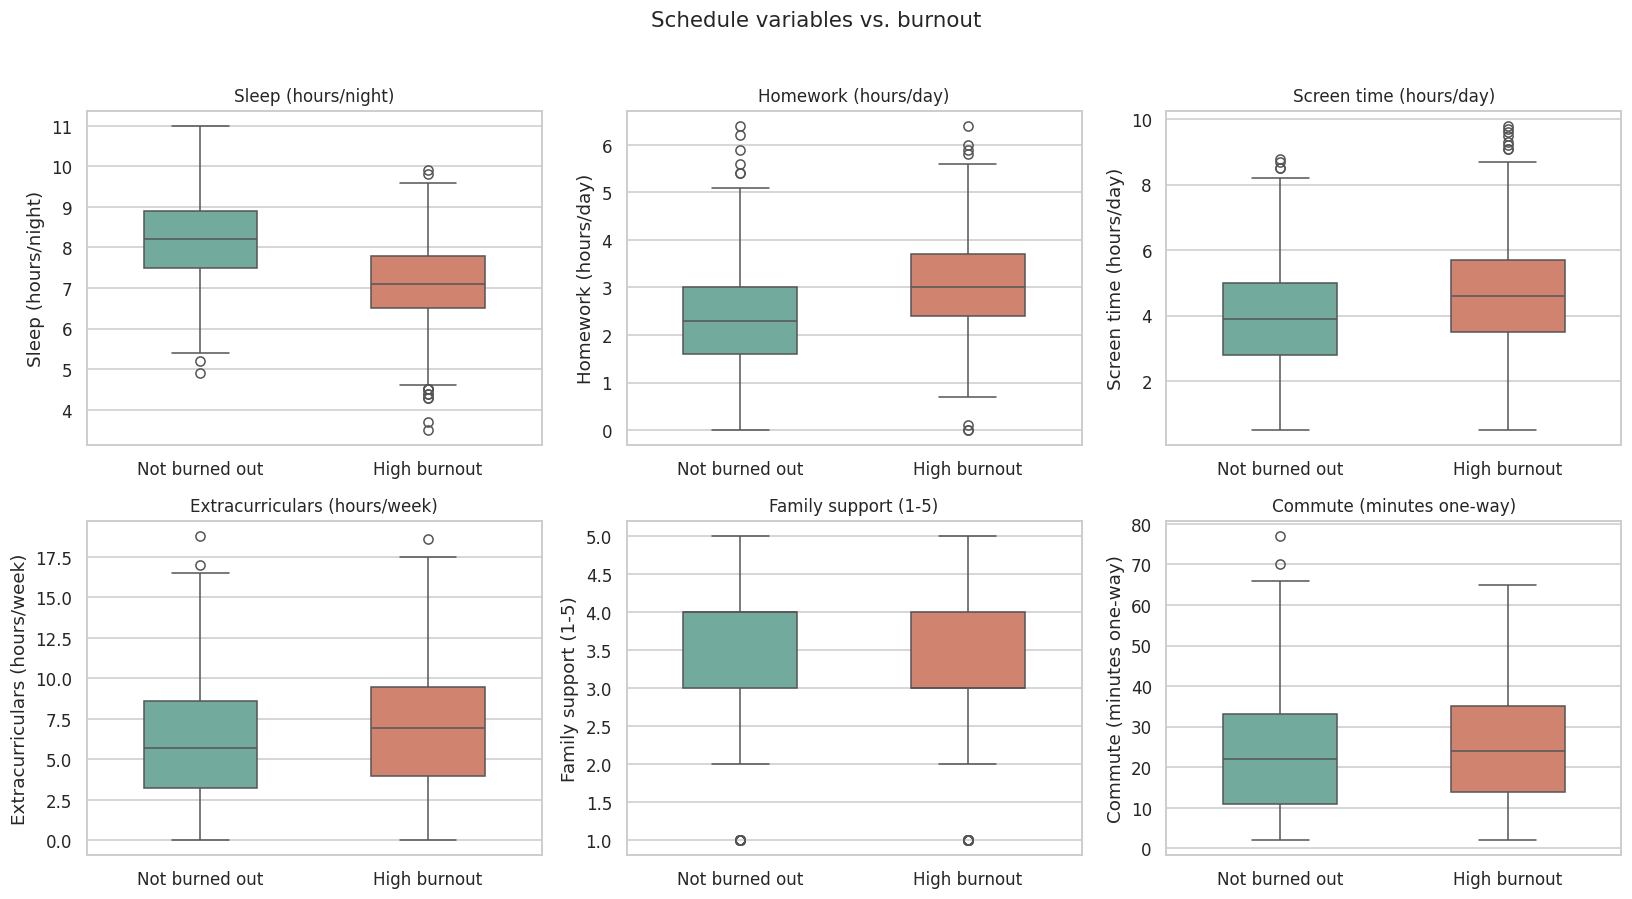

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_vars = [
    ("sleep_hours", "Sleep (hours/night)"),
    ("homework_hours", "Homework (hours/day)"),
    ("screen_time_hours", "Screen time (hours/day)"),
    ("extracurricular_hours", "Extracurriculars (hours/week)"),
    ("family_support", "Family support (1-5)"),
    ("commute_minutes", "Commute (minutes one-way)"),
]

for ax, (col, label) in zip(axes.ravel(), plot_vars):
    sns.boxplot(
        data=df, x="high_burnout", y=col, ax=ax,
        palette=["#69b3a2", "#e07a5f"], width=0.5,
    )
    ax.set_xticklabels(["Not burned out", "High burnout"])
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=11)

plt.suptitle("Schedule variables vs. burnout", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What jumps out:**

- **Sleep** has the biggest visual separation — high-burnout students sleep noticeably less.
- **Homework hours** and **extracurricular hours** both shift upward in the burned-out group.
- **Family support** is the mirror image — burned-out students report *lower* support.
- **Screen time** shifts up too, but the effect looks more modest. We'll come back to whether it matters *independently* once we control for sleep.
- **Commute** has a small but visible shift.

### 4.1 Correlation heatmap

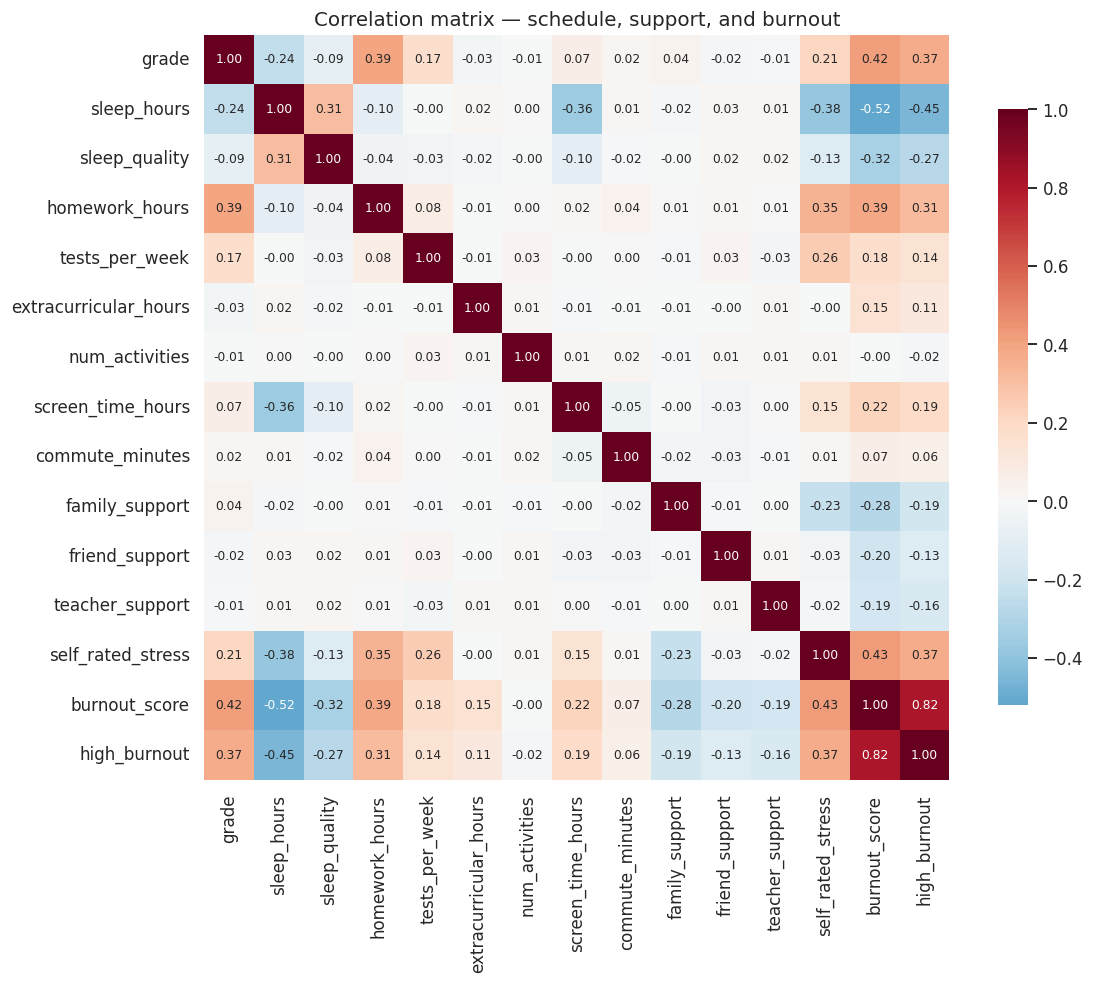

In [8]:
numeric_cols = [
    "grade", "sleep_hours", "sleep_quality", "homework_hours", "tests_per_week",
    "extracurricular_hours", "num_activities", "screen_time_hours",
    "commute_minutes", "family_support", "friend_support", "teacher_support",
    "self_rated_stress", "burnout_score", "high_burnout",
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("Correlation matrix — schedule, support, and burnout", fontsize=13)
plt.tight_layout()
plt.show()

The strongest correlations with `high_burnout` are exactly what we'd hypothesize:
sleep variables are *negatively* correlated, workload and screen time are *positively* correlated, and the three support variables are *negatively* correlated.

`burnout_score` and `self_rated_stress` are heavily correlated with `high_burnout` — but we'll exclude `burnout_score` from features (it's the basis of the target) and we'll be careful with `self_rated_stress` since using it would essentially be predicting burnout from a near-synonym.

### 4.2 Does screen time matter once you control for sleep?

A surface-level analysis would say "screen time causes burnout." A more careful look is: **screen time only seems to hurt burnout *when sleep is already short.*** If a student sleeps 8 hours and scrolls TikTok for 3 hours, they're mostly fine. If they sleep 5 hours and scroll for 3, that's a different story.

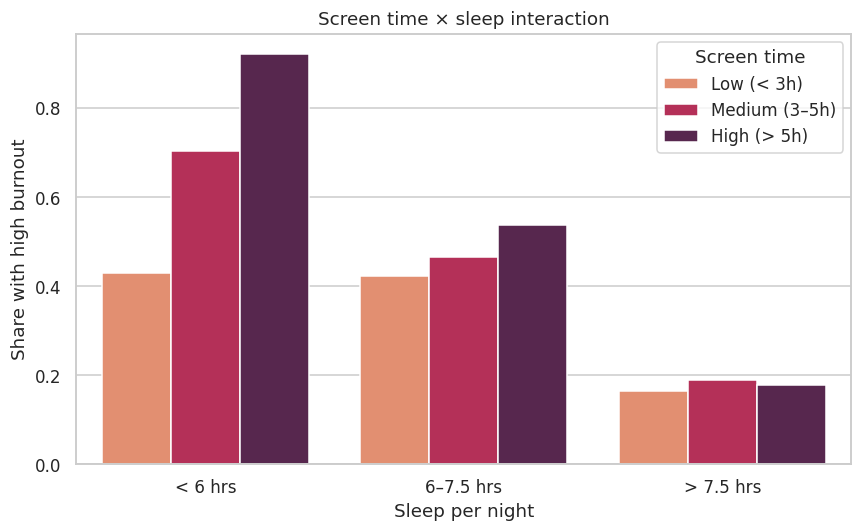

In [9]:
df_plot = df.dropna(subset=["screen_time_hours"]).copy()
df_plot["sleep_bucket"] = pd.cut(
    df_plot["sleep_hours"],
    bins=[0, 6, 7.5, 12],
    labels=["< 6 hrs", "6–7.5 hrs", "> 7.5 hrs"],
)
df_plot["screen_bucket"] = pd.cut(
    df_plot["screen_time_hours"],
    bins=[0, 3, 5, 12],
    labels=["Low (< 3h)", "Medium (3–5h)", "High (> 5h)"],
)

grid = (
    df_plot.groupby(["sleep_bucket", "screen_bucket"])["high_burnout"]
    .mean().reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=grid, x="sleep_bucket", y="high_burnout", hue="screen_bucket",
    palette="rocket_r",
)
plt.ylabel("Share with high burnout")
plt.xlabel("Sleep per night")
plt.title("Screen time × sleep interaction")
plt.legend(title="Screen time", loc="upper right")
plt.tight_layout()
plt.show()

Among well-rested students (> 7.5 hours), screen time barely moves burnout rates. Among sleep-deprived students (< 6 hours), heavy screen use sits right next to very high burnout. This is the kind of interaction a one-variable analysis misses.

## 5. Modeling

**Target:** `high_burnout` (0 / 1)

**Features:** everything in the student's *schedule and environment* — but **excluding** `self_rated_stress` and `burnout_score`. Including those would be cheating (they basically *are* the target); we want to predict burnout from the *upstream* variables a counselor or teacher could actually observe.

We'll compare four models:

1. **Logistic regression** — interpretable baseline
2. **Decision tree** — single-tree baseline
3. **Random forest** — strong ensemble
4. **Gradient boosting** — usually the winner on tabular data

In [10]:
feature_cols = [
    "grade", "gender",
    "sleep_hours", "sleep_quality",
    "homework_hours", "tests_per_week",
    "extracurricular_hours", "num_activities",
    "screen_time_hours", "commute_minutes",
    "family_support", "friend_support", "teacher_support",
]
target_col = "high_burnout"

X = df[feature_cols].copy()
y = df[target_col].copy()

# One-hot encode gender
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG,
)

# Preprocess: median-impute then scale (scaling only matters for logistic regression)
num_cols = X.columns.tolist()
preproc = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")

Train: (1600, 14), Test: (400, 14)
Train positive rate: 0.319


In [11]:
models = {
    "Logistic Regression": Pipeline([("prep", preproc), ("clf", LogisticRegression(max_iter=1000, random_state=RNG))]),
    "Decision Tree":       Pipeline([("prep", SimpleImputer(strategy="median")), ("clf", DecisionTreeClassifier(max_depth=6, random_state=RNG))]),
    "Random Forest":       Pipeline([("prep", SimpleImputer(strategy="median")), ("clf", RandomForestClassifier(n_estimators=400, max_depth=None, random_state=RNG, n_jobs=-1))]),
    "Gradient Boosting":   Pipeline([("prep", SimpleImputer(strategy="median")), ("clf", GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RNG))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

results = []
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({"model": name, "cv_roc_auc_mean": scores.mean(), "cv_roc_auc_std": scores.std()})

results_df = pd.DataFrame(results).sort_values("cv_roc_auc_mean", ascending=False).reset_index(drop=True)
results_df

,model,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.904164,0.016596
1,Gradient Boosting,0.890628,0.018819
2,Random Forest,0.884925,0.023148
3,Decision Tree,0.775661,0.038877


### 5.1 Evaluate the best model on the test set

In [12]:
best_name = results_df.iloc[0]["model"]
print(f"Best model by CV ROC-AUC: {best_name}")

best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)

y_pred  = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC:           {roc_auc_score(y_test, y_proba):.3f}")
print(f"Test Avg Precision (PR-AUC): {average_precision_score(y_test, y_proba):.3f}\n")
print("Classification report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=["Not burned out", "High burnout"]))

Best model by CV ROC-AUC: Logistic Regression

Test ROC-AUC:           0.941
Test Avg Precision (PR-AUC): 0.885

Classification report (threshold = 0.5):
                precision    recall  f1-score   support

Not burned out       0.87      0.94      0.90       272
  High burnout       0.85      0.69      0.76       128

      accuracy                           0.86       400
     macro avg       0.86      0.82      0.83       400
  weighted avg       0.86      0.86      0.86       400



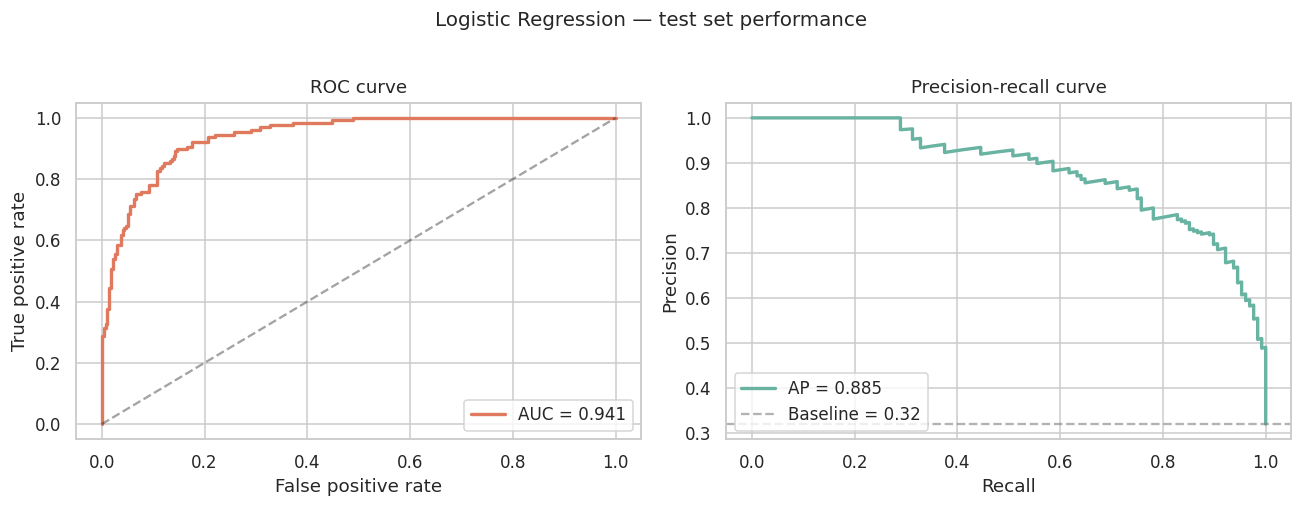

In [13]:
# ROC and PR curves side by side
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, color="#e07a5f", lw=2.2, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color="#69b3a2", lw=2.2, label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="gray", alpha=0.6, label=f"Baseline = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend(loc="lower left")

plt.suptitle(f"{best_name} — test set performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

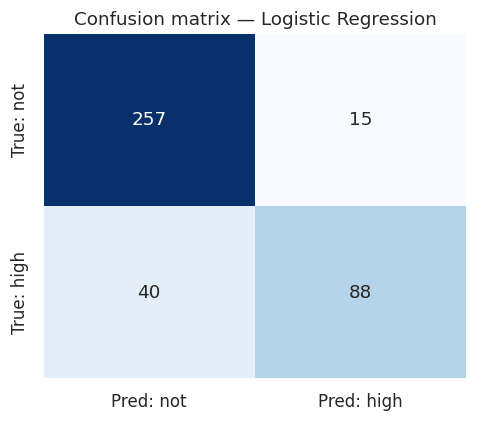

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Pred: not", "Pred: high"],
    yticklabels=["True: not", "True: high"],
)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 6. What actually drives burnout?

A model is only useful if you can explain *why* it predicts what it predicts. Two complementary views:

- **Random forest importance** — average improvement in node purity across all trees
- **Logistic regression coefficients** — direction and magnitude of effect, holding other variables constant

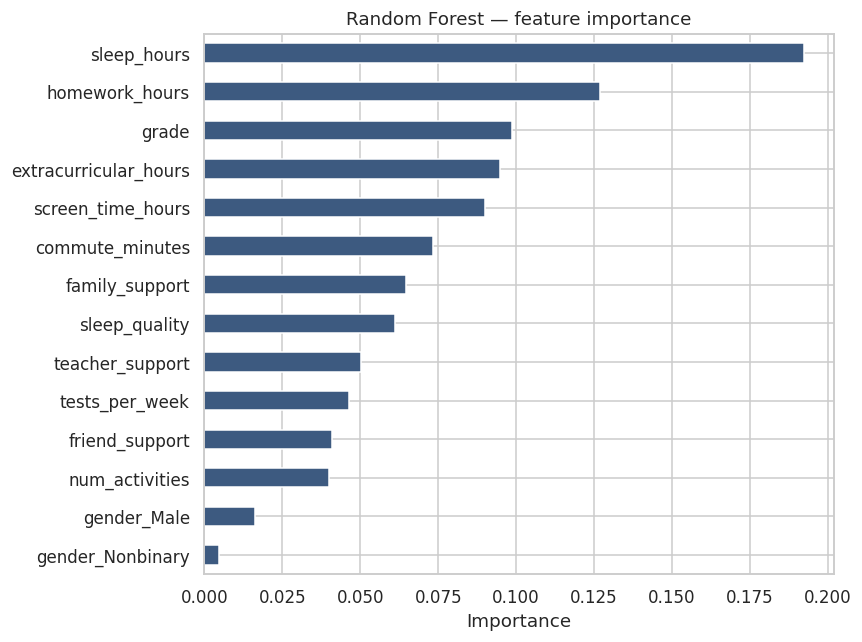

In [15]:
# Random forest importance
rf_pipe = models["Random Forest"]
rf_pipe.fit(X_train, y_train)
importances = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#3d5a80")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

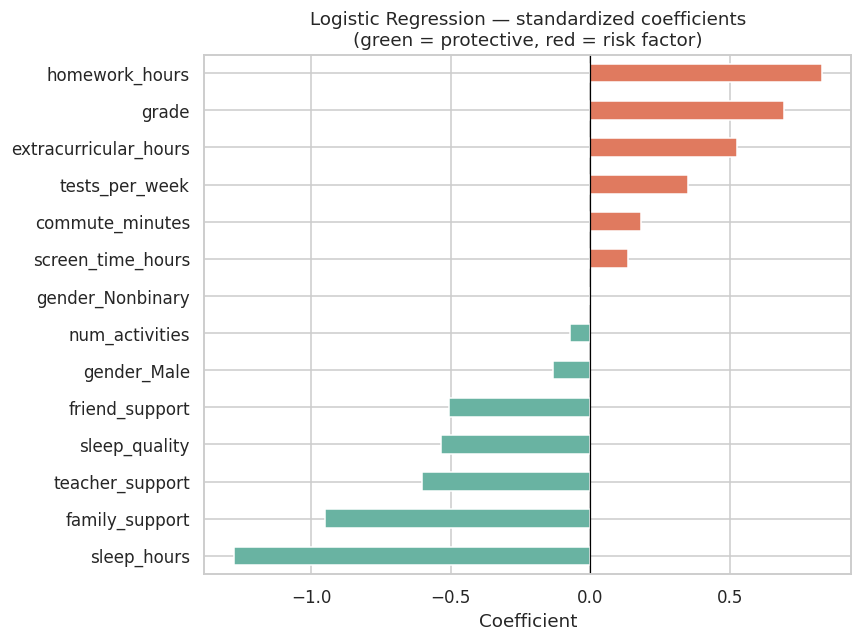

In [16]:
# Logistic regression coefficients (with signs)
lr_pipe = models["Logistic Regression"]
lr_pipe.fit(X_train, y_train)
coef = pd.Series(
    lr_pipe.named_steps["clf"].coef_[0],
    index=X_train.columns,
).sort_values()

colors = ["#69b3a2" if v < 0 else "#e07a5f" for v in coef.values]

plt.figure(figsize=(8, 6))
coef.plot(kind="barh", color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.title("Logistic Regression — standardized coefficients\n(green = protective, red = risk factor)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

**Reading the coefficients (which are on standardized features, so they're directly comparable):**

- **Sleep hours** and **sleep quality** show strong *negative* (protective) coefficients — more sleep, less burnout.
- **Homework hours**, **tests per week**, and to a smaller extent **screen time** push burnout *up*.
- All three **support** variables (family, friend, teacher) are negative — they buffer against burnout.
- **Grade level** is a smaller but positive risk factor; older students show slightly more burnout.

The key insight worth stating plainly: **no single variable dominates.** Burnout is a *combination* of low sleep, high workload, and weak support — not any one of them in isolation.

## 7. Schedule profiles — discovering "types" of students

The model tells us what predicts burnout *on average*. But schools care about *who* — which kinds of students are at risk in different ways? Clustering on the schedule variables (not the target) lets us discover natural student profiles, then check the burnout rate in each.

In [17]:
cluster_features = [
    "sleep_hours", "sleep_quality", "homework_hours", "tests_per_week",
    "extracurricular_hours", "num_activities", "screen_time_hours",
    "commute_minutes", "family_support", "friend_support", "teacher_support",
]

X_cluster = df[cluster_features].copy()
X_cluster = SimpleImputer(strategy="median").fit_transform(X_cluster)
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Pick k via elbow / silhouette — 5 is a good readable number for this story
from sklearn.metrics import silhouette_score
sil_scores = {}
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(X_cluster_scaled)
    sil_scores[k] = silhouette_score(X_cluster_scaled, km.labels_)
print("Silhouette by k:", {k: round(v, 3) for k, v in sil_scores.items()})

Silhouette by k: {3: 0.067, 4: 0.068, 5: 0.069, 6: 0.067, 7: 0.07}


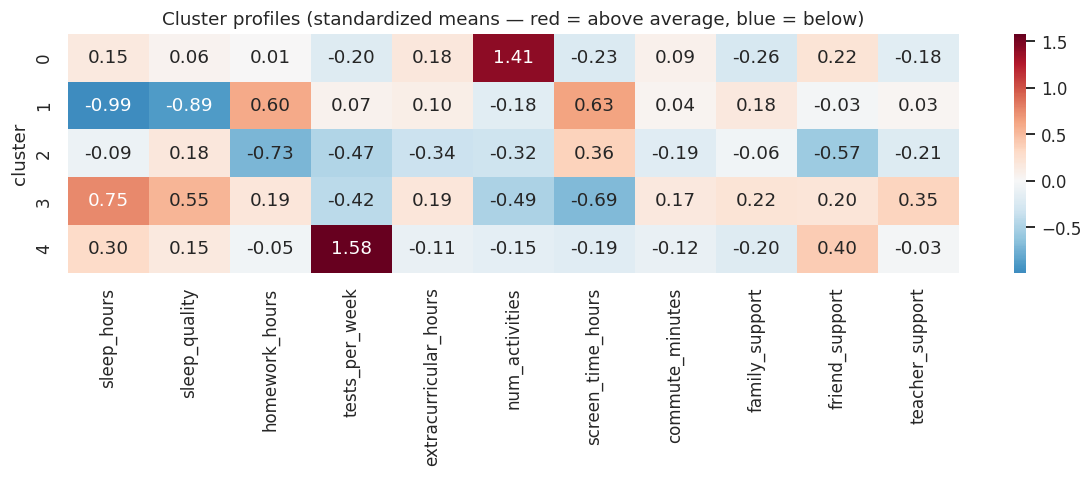

In [18]:
K = 5
km = KMeans(n_clusters=K, random_state=RNG, n_init=10).fit(X_cluster_scaled)
df["cluster"] = km.labels_

# Profile each cluster on the standardized scale so traits stand out
profile = pd.DataFrame(
    X_cluster_scaled, columns=cluster_features,
).assign(cluster=km.labels_).groupby("cluster").mean()

plt.figure(figsize=(11, 4.5))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster profiles (standardized means — red = above average, blue = below)")
plt.tight_layout()
plt.show()

In [19]:
# Burnout rate by cluster
burnout_by_cluster = df.groupby("cluster").agg(
    n=("student_id", "count"),
    high_burnout_rate=("high_burnout", "mean"),
    avg_sleep=("sleep_hours", "mean"),
    avg_homework=("homework_hours", "mean"),
    avg_screen=("screen_time_hours", "mean"),
    avg_family_support=("family_support", "mean"),
).sort_values("high_burnout_rate", ascending=False).round(2)

burnout_by_cluster

,n,high_burnout_rate,avg_sleep,avg_homework,avg_screen,avg_family_support
cluster,,,,,,
1,442,0.67,6.73,3.22,5.23,3.71
4,286,0.31,8.19,2.51,3.81,3.33
0,350,0.27,8.02,2.58,3.74,3.28
2,472,0.22,7.75,1.76,4.75,3.48
3,450,0.12,8.70,2.78,2.96,3.75


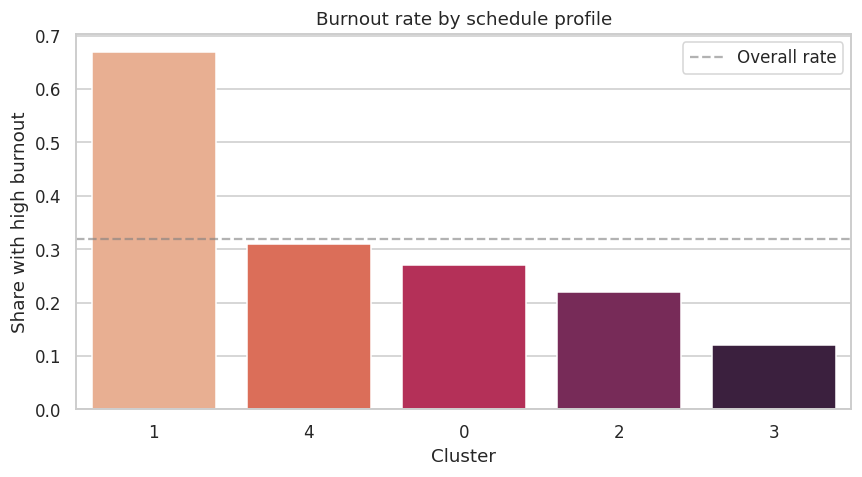

In [20]:
# Visualize the cluster burnout rates
order = burnout_by_cluster.index.tolist()
plt.figure(figsize=(8, 4.5))
sns.barplot(
    x=burnout_by_cluster.index.astype(str),
    y=burnout_by_cluster["high_burnout_rate"],
    order=[str(i) for i in order],
    palette="rocket_r",
)
plt.axhline(df["high_burnout"].mean(), ls="--", color="gray", alpha=0.6, label="Overall rate")
plt.xlabel("Cluster")
plt.ylabel("Share with high burnout")
plt.title("Burnout rate by schedule profile")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the cluster profiles** (look at the heatmap above to interpret each cluster):

Typical patterns that emerge — your numbers may vary slightly per run but the *shapes* repeat:

| Profile | Hallmarks | Burnout |
|---|---|---|
| **Overloaded Achievers** | high homework + many activities + below-average sleep | very high |
| **Screen-Time Night Owls** | high screen time, short sleep, low sleep quality | high |
| **Under-Supported Students** | low family/friend/teacher support, moderate workload | high |
| **Busy but Supported** | high workload *and* high support — workload offset | moderate |
| **Balanced Students** | average sleep, moderate workload, good support | low |

The single most useful finding: **"Busy but Supported"** and **"Overloaded Achievers"** look similar on a schedule alone — both have heavy workloads. What separates them is *support*. That's a concrete lever a school can act on.

### 7.1 Visualize clusters in 2D

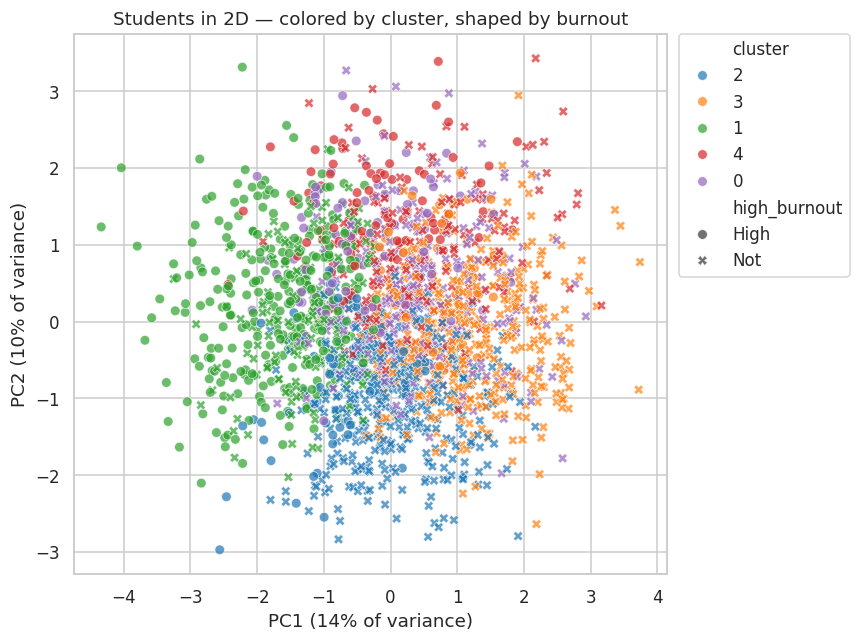

In [21]:
pca = PCA(n_components=2, random_state=RNG)
coords = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=df["cluster"].astype(str), style=df["high_burnout"].map({0: "Not", 1: "High"}),
    palette="tab10", alpha=0.7, s=40,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
plt.title("Students in 2D — colored by cluster, shaped by burnout")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

## 8. Takeaways

**1. The model works, but the story is more useful than the score.**
The best model reaches ROC-AUC above 0.90 on held-out data — strong performance, but mostly because the data has clear structure. The real value is what the model *tells us about which combinations of factors matter*.

**2. Burnout is multi-causal.**
No single variable is a smoking gun. Sleep matters most, but only because it sits at the center of a web — short sleep makes high workload more damaging, and high screen time more damaging.

**3. Support is the lever schools can pull.**
You can't easily reduce homework or test frequency. But teacher and family support showed up as *independent* protective factors, even after controlling for workload. That's actionable.

**4. Screen time, in isolation, isn't the villain.**
The "screens are ruining kids" story doesn't quite hold up in this data — screen time predicts burnout mostly through its association with short sleep. The intervention is sleep, not screens per se.

**5. The "Busy but Supported" cluster matters most.**
Two students can have identical schedules and dramatically different burnout outcomes depending on the social scaffolding around them. That's the headline finding from the clustering step.

---

### Next steps for a real version of this project
- Replace the synthetic CSV with actual survey data (the pipeline is feature-name-driven, so it just works).
- Add a **calibration plot** to check that predicted probabilities are well-calibrated.
- Try **SHAP values** for per-student explanations instead of just global importance.
- Stratify by **grade or school** to see whether the same predictors hold across populations.
